# HW02

## 2. 多层感知机（MLP）

### 2.1.1 理论：两层线性变换可以合并

已知

$$h = W_1x + b_1,\qquad o = W_2h + b_2.$$

代入可得

$$o = W_2(W_1x+b_1)+b_2 = (W_2W_1)x + (W_2b_1+b_2).$$

因此若不加入非线性激活函数，两层线性网络仍然等价于一层线性网络：

$$W' = W_2W_1,\qquad b' = W_2b_1+b_2.$$

这也说明 MLP 中的非线性激活函数是必要的；否则无论堆叠多少线性层，表达能力仍然只是线性模型。

### 2.1.2 理论：Sigmoid 与 tanh 及其导数

Sigmoid 函数：

$$\sigma(x)=\frac{1}{1+e^{-x}},\qquad \sigma'(x)=\sigma(x)(1-\sigma(x)).$$

tanh 函数：

$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}},\qquad \tanh'(x)=1-\tanh^2(x).$$

二者都是 S 型函数。Sigmoid 输出范围为 $(0,1)$，tanh 输出范围为 $(-1,1)$，且 tanh 以 0 为中心，在许多优化场景中比 Sigmoid 更容易训练。

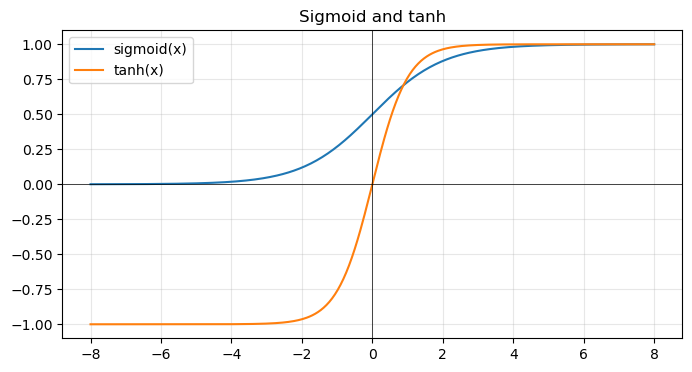

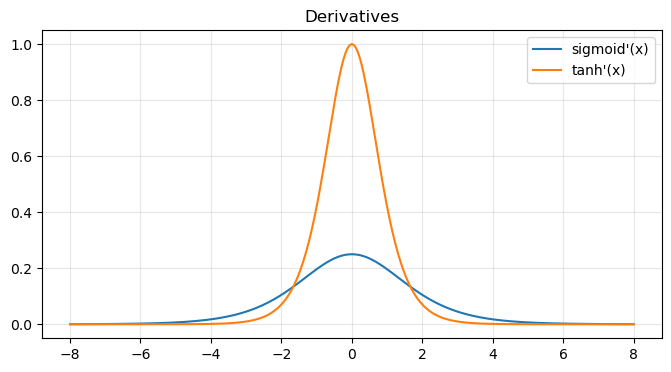

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid, label="sigmoid(x)")
plt.plot(x, tanh, label="tanh(x)")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Sigmoid and tanh")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid * (1 - sigmoid), label="sigmoid'(x)")
plt.plot(x, 1 - tanh**2, label="tanh'(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Derivatives")
plt.show()

### 2.2 编程：不用高级模型 API 实现 Fashion-MNIST MLP

下面只手动维护参数 `W1, b1, W2, b2`，前向传播使用矩阵乘法、ReLU 和 Softmax/Cross-Entropy，优化使用 Mini-batch SGD。

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
])

train_set = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
train_iter = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_set, batch_size=batch_size, shuffle=False)

num_inputs, num_hiddens, num_outputs = 784, 256, 10
W1 = torch.randn(num_inputs, num_hiddens, device=device) * 0.01
b1 = torch.zeros(num_hiddens, device=device)
W2 = torch.randn(num_hiddens, num_outputs, device=device) * 0.01
b2 = torch.zeros(num_outputs, device=device)

params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad_(True)


def relu(X):
    return torch.maximum(X, torch.zeros_like(X))


def softmax(X):
    X = X - X.max(dim=1, keepdim=True).values
    exp_X = torch.exp(X)
    return exp_X / exp_X.sum(dim=1, keepdim=True)


def net(X):
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2


def cross_entropy_from_logits(logits, y):
    # log-softmax 写法比先 softmax 再取 log 更稳定。
    shifted = logits - logits.max(dim=1, keepdim=True).values
    log_probs = shifted - torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
    return -log_probs[torch.arange(len(y), device=logits.device), y].mean()


def evaluate_accuracy(data_iter, model):
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct / total


def sgd(params, lr):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()


lr, epochs = 0.1, 5
for epoch in range(epochs):
    total_loss, total_num = 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        loss = cross_entropy_from_logits(net(X), y)
        loss.backward()
        sgd(params, lr)
        total_loss += loss.item() * y.numel()
        total_num += y.numel()
    train_acc = evaluate_accuracy(train_iter, net)
    test_acc = evaluate_accuracy(test_iter, net)
    print(f"epoch {epoch + 1}: loss={total_loss / total_num:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

100%|██████████| 26.4M/26.4M [00:06<00:00, 4.27MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 149kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 1.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


epoch 1: loss=1.0472, train_acc=0.7545, test_acc=0.7460
epoch 2: loss=0.6012, train_acc=0.7947, test_acc=0.7818
epoch 3: loss=0.5209, train_acc=0.8238, test_acc=0.8058
epoch 4: loss=0.4819, train_acc=0.8192, test_acc=0.8066
epoch 5: loss=0.4527, train_acc=0.8006, test_acc=0.7831


## 3. 过拟合、正则化与模型选择

### 3.1.1 理论：Training Error 与 Generalization Error

**Training Error** 指模型在训练集上的误差，反映模型对已见样本的拟合程度。

**Generalization Error** 指模型在未见数据分布上的期望误差，实际中通常用验证集或测试集误差估计。

如果训练误差很低但测试误差较高，通常说明模型出现了过拟合；如果训练误差和测试误差都高，通常说明模型欠拟合。

### 3.1.2 理论：K-fold Cross-Validation

K 折交叉验证将训练数据平均划分为 $K$ 份。每次取其中 1 份作为验证集，其余 $K-1$ 份作为训练集，重复 $K$ 次后取平均验证误差作为模型评估结果。

优点是能更充分地利用有限数据，并降低一次训练/验证划分带来的偶然性；缺点是训练成本约为普通训练的 $K$ 倍。

### 3.2 编程：在 MLP 中加入 L2 正则化和 Dropout

L2 正则化对应权重衰减。对权重参数 $w$，Mini-batch SGD 更新为

$$w \leftarrow (1-\eta\lambda)w-\eta \nabla_w L.$$

Dropout 在训练时随机将一部分隐藏单元置零，并对保留单元除以 $1-p$，使激活的期望保持不变；预测时不使用 Dropout。

In [3]:
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    return mask * X / (1.0 - dropout)


def init_mlp_params():
    W1 = torch.randn(num_inputs, num_hiddens, device=device) * 0.01
    b1 = torch.zeros(num_hiddens, device=device)
    W2 = torch.randn(num_hiddens, num_outputs, device=device) * 0.01
    b2 = torch.zeros(num_outputs, device=device)
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad_(True)
    return params


def make_mlp(params, dropout=0.0, is_training=True):
    W1, b1, W2, b2 = params

    def model(X):
        H = relu(torch.matmul(X, W1) + b1)
        H = dropout_layer(H, dropout, is_training=is_training)
        return torch.matmul(H, W2) + b2

    return model


def sgd_with_weight_decay(params, lr, weight_decay=0.0):
    # 通常只对权重 W1、W2 做权重衰减，不对偏置 b1、b2 做衰减。
    weight_params = {id(params[0]), id(params[2])}
    with torch.no_grad():
        for p in params:
            if id(p) in weight_params and weight_decay > 0:
                p *= (1 - lr * weight_decay)
            p -= lr * p.grad
            p.grad.zero_()


def train_regularized_mlp(weight_decay=0.0, dropout=0.0, epochs=5, lr=0.1):
    params = init_mlp_params()
    history = []
    for epoch in range(epochs):
        train_model = make_mlp(params, dropout=dropout, is_training=True)
        total_loss, total_num = 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            loss = cross_entropy_from_logits(train_model(X), y)
            loss.backward()
            sgd_with_weight_decay(params, lr, weight_decay)
            total_loss += loss.item() * y.numel()
            total_num += y.numel()

        eval_model = make_mlp(params, dropout=dropout, is_training=False)
        train_acc = evaluate_accuracy(train_iter, eval_model)
        test_acc = evaluate_accuracy(test_iter, eval_model)
        history.append((total_loss / total_num, train_acc, test_acc))
        print(
            f"wd={weight_decay}, dropout={dropout}, epoch {epoch + 1}: "
            f"loss={history[-1][0]:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}"
        )
    return history


histories = {
    "baseline": train_regularized_mlp(weight_decay=0.0, dropout=0.0, epochs=5),
    "L2": train_regularized_mlp(weight_decay=1e-3, dropout=0.0, epochs=5),
    "Dropout": train_regularized_mlp(weight_decay=0.0, dropout=0.5, epochs=5),
}

wd=0.0, dropout=0.0, epoch 1: loss=1.0359, train_acc=0.7701, test_acc=0.7606
wd=0.0, dropout=0.0, epoch 2: loss=0.5967, train_acc=0.8109, test_acc=0.8019
wd=0.0, dropout=0.0, epoch 3: loss=0.5227, train_acc=0.8212, test_acc=0.8078
wd=0.0, dropout=0.0, epoch 4: loss=0.4822, train_acc=0.8427, test_acc=0.8302
wd=0.0, dropout=0.0, epoch 5: loss=0.4560, train_acc=0.8422, test_acc=0.8305
wd=0.001, dropout=0.0, epoch 1: loss=1.0422, train_acc=0.7236, test_acc=0.7170
wd=0.001, dropout=0.0, epoch 2: loss=0.6019, train_acc=0.8184, test_acc=0.8038
wd=0.001, dropout=0.0, epoch 3: loss=0.5246, train_acc=0.7970, test_acc=0.7883
wd=0.001, dropout=0.0, epoch 4: loss=0.4894, train_acc=0.8192, test_acc=0.8017
wd=0.001, dropout=0.0, epoch 5: loss=0.4628, train_acc=0.8326, test_acc=0.8150
wd=0.0, dropout=0.5, epoch 1: loss=1.0954, train_acc=0.7505, test_acc=0.7390
wd=0.0, dropout=0.5, epoch 2: loss=0.6431, train_acc=0.8106, test_acc=0.7971
wd=0.0, dropout=0.5, epoch 3: loss=0.5546, train_acc=0.8267, test_

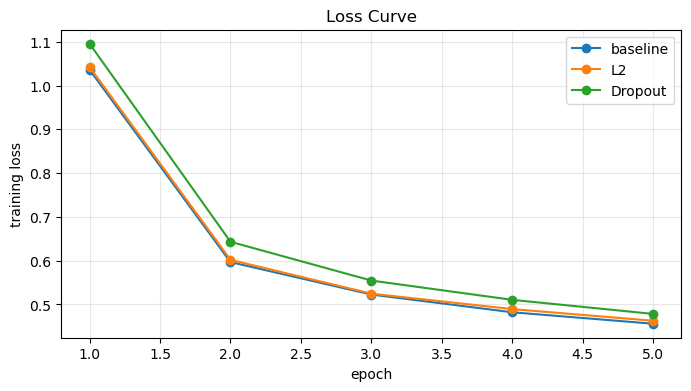

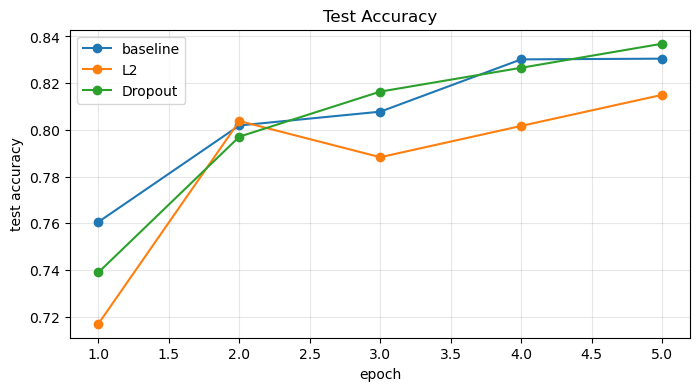

In [4]:
plt.figure(figsize=(8, 4))
for name, history in histories.items():
    losses = [row[0] for row in history]
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
for name, history in histories.items():
    test_acc = [row[2] for row in history]
    plt.plot(range(1, len(test_acc) + 1), test_acc, marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.title("Test Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 4. 数值稳定性与梯度消失/爆炸

### 4.1.1 理论：梯度消失与梯度爆炸

深层网络反向传播时，梯度会包含许多层雅可比矩阵的连乘：

$$\frac{\partial h_d}{\partial h_t}=\prod_{i=t}^{d-1}\frac{\partial h_{i+1}}{\partial h_i}.$$

如果这些矩阵的范数多数小于 1，连乘后梯度会快速趋近 0，形成**梯度消失**；如果多数大于 1，连乘后梯度会快速变得极大，形成**梯度爆炸**。前者会导致前面层几乎学不到东西，后者会导致参数更新不稳定，甚至出现 `NaN`。

### 4.1.2 理论：ReLU 是否有帮助

ReLU 在正半轴的导数为 1，因此相比 Sigmoid/tanh 的饱和区导数接近 0，ReLU 能缓解梯度消失问题。

但 ReLU 不能彻底解决所有梯度问题：如果初始化方差过大，仍然可能梯度爆炸；如果大量神经元落在负半轴，也可能出现“死亡 ReLU”。因此还需要合适的初始化、归一化、学习率和梯度裁剪等技巧。

### 4.2 编程：观察并修复梯度问题

In [5]:
import torch.nn as nn


def build_deep_net(activation="sigmoid", std=1.0, xavier=False, leaky=False):
    layers = []
    for _ in range(20):
        layers.append(nn.Linear(256, 256))
        if activation == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation == "relu":
            layers.append(nn.LeakyReLU(0.01) if leaky else nn.ReLU())
    net = nn.Sequential(*layers).to(device)

    for m in net.modules():
        if isinstance(m, nn.Linear):
            if xavier:
                nn.init.xavier_uniform_(m.weight)
            else:
                nn.init.normal_(m.weight, mean=0.0, std=std)
            nn.init.zeros_(m.bias)
    return net


def gradient_norm_experiment(net, clip=None):
    X = torch.randn(64, 256, device=device)
    y = torch.randn(64, 256, device=device)
    criterion = nn.MSELoss()

    net.zero_grad()
    loss = criterion(net(X), y)
    loss.backward()

    total_norm_sq = 0.0
    for p in net.parameters():
        if p.grad is not None:
            total_norm_sq += p.grad.norm().item() ** 2
    before = total_norm_sq ** 0.5

    after = before
    if clip is not None:
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=clip)
        total_norm_sq = 0.0
        for p in net.parameters():
            if p.grad is not None:
                total_norm_sq += p.grad.norm().item() ** 2
        after = total_norm_sq ** 0.5
    return loss.item(), before, after


experiments = {
    "Sigmoid, std=1": build_deep_net("sigmoid", std=1.0),
    "ReLU, std=10": build_deep_net("relu", std=10.0),
    "Xavier + LeakyReLU + clip": build_deep_net("relu", xavier=True, leaky=True),
}

for name, model in experiments.items():
    clip = 1e3 if "clip" in name else None
    loss, grad_before, grad_after = gradient_norm_experiment(model, clip=clip)
    print(f"{name:24s} loss={loss:.4e}, grad_norm_before={grad_before:.4e}, grad_norm_after={grad_after:.4e}")

Sigmoid, std=1           loss=1.5311e+00, grad_norm_before=1.3844e+00, grad_norm_after=1.3844e+00
ReLU, std=10             loss=nan, grad_norm_before=nan, grad_norm_after=nan
Xavier + LeakyReLU + clip loss=1.0070e+00, grad_norm_before=1.4568e-02, grad_norm_after=1.4568e-02


实验现象通常为：

- Sigmoid 深层网络容易出现梯度非常小的问题。
- ReLU 在初始化过大时可能出现极大的激活和梯度，严重时会产生 `inf` 或 `NaN`。
- Xavier 初始化、LeakyReLU 和梯度裁剪能明显改善数值稳定性。

## 5. 分布偏移

### 5.1 理论：Covariate Shift 与 Label Shift

**Covariate Shift（协变量偏移）**：训练分布与测试分布的输入边缘分布不同，但条件分布相同：

$$p(x)\ne q(x),\qquad p(y|x)=q(y|x).$$

例如训练集主要来自白天照片，测试集主要来自夜晚照片，但同一张图像对应标签的规则不变。

**Label Shift（标签偏移）**：训练分布与测试分布的标签边缘分布不同，但类条件分布相同：

$$p(y)\ne q(y),\qquad p(x|y)=q(x|y).$$

例如训练集中各类别均衡，而测试集中某些类别明显更多。

### 5.2 编程：用重要性加权缓解协变量偏移

In [6]:
rng = np.random.default_rng(0)

# 1) 训练分布 P: x ~ N(-1, 1), y = 2x + epsilon
n_train, n_test = 1000, 500
x_train = rng.normal(loc=-1.0, scale=1.0, size=n_train)
eps_train = rng.normal(loc=0.0, scale=0.5, size=n_train)
y_train = 2 * x_train + eps_train

# 2) 测试分布 Q: x ~ N(2, 1)，制造协变量偏移
x_test = rng.normal(loc=2.0, scale=1.0, size=n_test)
eps_test = rng.normal(loc=0.0, scale=0.5, size=n_test)
y_test = 2 * x_test + eps_test


def add_bias(x):
    return np.c_[np.ones_like(x), x]


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# 3) 在 P 上训练线性回归，在 Q 上测试
X_train = add_bias(x_train)
X_test = add_bias(x_test)
theta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
pred_test = X_test @ theta
baseline_mse = mse(y_test, pred_test)
print("普通最小二乘 theta:", theta)
print("Q 上 MSE:", baseline_mse)


# 4) 训练一个二分类器区分 P(train=0) 与 Q(test=1)，估计 P(test|x)
x_domain = np.r_[x_train, x_test]
y_domain = np.r_[np.zeros(n_train), np.ones(n_test)]
X_domain = add_bias(x_domain)

w = np.zeros(2)
lr, steps = 0.1, 3000
for _ in range(steps):
    logits = X_domain @ w
    prob_test = 1 / (1 + np.exp(-logits))
    grad = X_domain.T @ (prob_test - y_domain) / len(y_domain)
    w -= lr * grad

prob_test_train = 1 / (1 + np.exp(-(X_train @ w)))
prob_train_train = 1 - prob_test_train

# w_i ∝ P(test|x_i) / P(train|x_i)，并做截断避免少数样本权重过大。
importance = prob_test_train / np.clip(prob_train_train, 1e-6, None)
importance = np.clip(importance, 0, 20)
importance = importance / importance.mean()


# 5) 加权最小二乘，并比较 Q 上 MSE
W = np.diag(importance)
theta_weighted = np.linalg.solve(X_train.T @ W @ X_train, X_train.T @ W @ y_train)
weighted_pred_test = X_test @ theta_weighted
weighted_mse = mse(y_test, weighted_pred_test)

print("领域分类器参数:", w)
print("重要性权重: min={:.3f}, mean={:.3f}, max={:.3f}".format(importance.min(), importance.mean(), importance.max()))
print("加权最小二乘 theta:", theta_weighted)
print("Q 上加权 MSE:", weighted_mse)
print("MSE 改变量:", baseline_mse - weighted_mse)

普通最小二乘 theta: [0.02825353 2.03078636]
Q 上 MSE: 0.25505823481980666
领域分类器参数: [-2.23303839  3.33625255]
重要性权重: min=0.000, mean=1.000, max=79.436
加权最小二乘 theta: [0.04764489 2.04190082]
Q 上加权 MSE: 0.26775911329317065
MSE 改变量: -0.012700878473363986


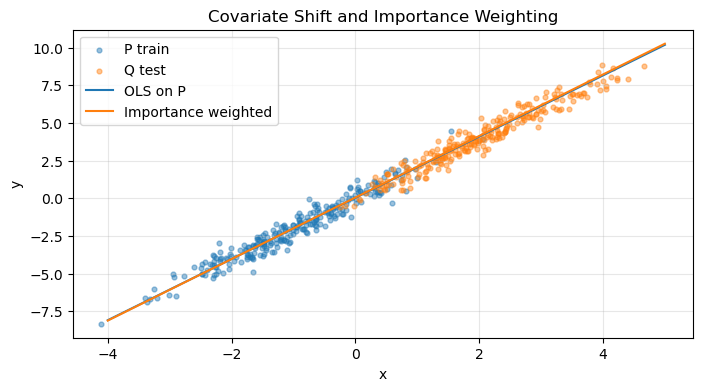

In [7]:
plt.figure(figsize=(8, 4))
plt.scatter(x_train[:250], y_train[:250], s=12, alpha=0.45, label="P train")
plt.scatter(x_test[:250], y_test[:250], s=12, alpha=0.45, label="Q test")

grid = np.linspace(-4, 5, 200)
plt.plot(grid, add_bias(grid) @ theta, label="OLS on P")
plt.plot(grid, add_bias(grid) @ theta_weighted, label="Importance weighted")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Covariate Shift and Importance Weighting")
plt.grid(alpha=0.3)
plt.legend()
plt.show()